In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)

df = pd.read_stata(
    r'C:\\Users\\honor\\Downloads\\GSS_stata\\gss7224_r2.dta',
    convert_categoricals=False
)

print(df.head())

   year  id  wrkstat  hrs1  hrs2  evwork    occ  prestige  wrkslf  wrkgovt  \
0  1972   1      1.0   NaN   NaN     NaN  205.0      50.0     2.0      NaN   
1  1972   2      5.0   NaN   NaN     1.0  441.0      45.0     2.0      NaN   
2  1972   3      2.0   NaN   NaN     NaN  270.0      44.0     2.0      NaN   
3  1972   4      1.0   NaN   NaN     NaN    1.0      57.0     2.0      NaN   
4  1972   5      7.0   NaN   NaN     1.0  385.0      40.0     2.0      NaN   

   commute  industry  occ80  prestg80  indus80  indus07  occonet  found  \
0      NaN     609.0    NaN       NaN      NaN      NaN      NaN    1.0   
1      NaN     338.0    NaN       NaN      NaN      NaN      NaN    1.0   
2      NaN     718.0    NaN       NaN      NaN      NaN      NaN    0.0   
3      NaN     319.0    NaN       NaN      NaN      NaN      NaN    1.0   
4      NaN     448.0    NaN       NaN      NaN      NaN      NaN    1.0   

    occ10  occindv  occstatus  occtag  prestg10  prestg105plus  indus10  \
0   5

In [2]:
df_96 = df.loc[df["year"] >= 1996]          # no copy
# or if you really need a copy of the slice:
# df_96 = df.loc[df["year"] >= 1996].copy(deep=False)  # shallow copy

In [3]:
df_96["year"].describe()

count    43319.000000
mean      2010.447933
std          9.061920
min       1996.000000
25%       2002.000000
50%       2010.000000
75%       2021.000000
max       2024.000000
Name: year, dtype: float64

In [4]:
print(df.columns.tolist())

['year', 'id', 'wrkstat', 'hrs1', 'hrs2', 'evwork', 'occ', 'prestige', 'wrkslf', 'wrkgovt', 'commute', 'industry', 'occ80', 'prestg80', 'indus80', 'indus07', 'occonet', 'found', 'occ10', 'occindv', 'occstatus', 'occtag', 'prestg10', 'prestg105plus', 'indus10', 'indstatus', 'indtag', 'marital', 'martype', 'agewed', 'divorce', 'widowed', 'spwrksta', 'sphrs1', 'sphrs2', 'spevwork', 'cowrksta', 'cowrkslf', 'coevwork', 'cohrs1', 'cohrs2', 'spocc', 'sppres', 'spwrkslf', 'spind', 'spocc80', 'sppres80', 'spind80', 'spocc10', 'spoccindv', 'spoccstatus', 'spocctag', 'sppres10', 'sppres105plus', 'spind10', 'spindstatus', 'spindtag', 'coocc10', 'coind10', 'paocc16', 'papres16', 'pawrkslf', 'paind16', 'paocc80', 'papres80', 'paind80', 'paocc10', 'paoccindv', 'paoccstatus', 'paocctag', 'papres10', 'papres105plus', 'paind10', 'paindstatus', 'paindtag', 'maocc80', 'mapres80', 'mawrkslf', 'maind80', 'maocc10', 'maoccindv', 'maoccstatus', 'maocctag', 'mapres10', 'mapres105plus', 'maind10', 'maindstatus'

In [5]:
model_1_vars = [
    # Depression outcome
    "happy",          # or your depression index
    "life",
    "health",
    "goodlife",
    # Education
    "educ",           # or degree (use only one)
    #"anomia1", "anomia2", "anomia3", "anomia4", "anomia5", "anomia6",
    #"anomia7",
    #"anomia8", "anomia9",

    # Religiosity (components or composite inputs)
    "attend",
    "pray",
    "reliten",

    # Core controls
    "age",
    "sex",
    "race",
    "year",
    "region"
]

In [6]:
coverage = (
    df_96
    .groupby("year")[model_1_vars]
    .apply(lambda x: x.notna().any())
    .astype(int)
)

coverage

,happy,life,health,goodlife,educ,attend,pray,reliten,age,sex,race,year,region
year,,,,,,,,,,,,,
1996,1,1,1,1,1,1,1,1,1,1,1,1,1
1998,1,1,1,1,1,1,1,1,1,1,1,1,1
2000,1,1,1,1,1,1,1,1,1,1,1,1,1
2002,1,1,1,1,1,1,1,1,1,1,1,1,1
2004,1,1,1,1,1,1,1,1,1,1,1,1,1
2006,1,1,1,1,1,1,1,1,1,1,1,1,1
2008,1,1,1,1,1,1,1,1,1,1,1,1,1
2010,1,1,1,1,1,1,1,1,1,1,1,1,1
2012,1,1,1,1,1,1,1,1,1,1,1,1,1


In [7]:
def print_variable_classes(df_96, variables, max_unique=20):
    for var in variables:
        print(f"\n=== {var} ===")

        if var not in df_96.columns:
            print("⚠️  Variable not found in DataFrame")
            continue

        series = df_96[var]
        dtype = series.dtype

        print(f"Data type: {dtype}")

        unique_vals = series.dropna().unique()
        n_unique = len(unique_vals)

        # Heuristic: treat as categorical if few unique values
        if n_unique <= max_unique:
            print(f"Number of classes: {n_unique}")
            print("Classes:", sorted(unique_vals))
        else:
            print(f"Unique values: {n_unique} (treated as continuous)")
            print(f"Min: {series.min()}, Max: {series.max()}")

In [8]:
print_variable_classes(df_96, model_1_vars)


=== happy ===
Data type: float64
Number of classes: 3
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]

=== life ===
Data type: float64
Number of classes: 3
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]

=== health ===
Data type: float64
Number of classes: 4
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

=== goodlife ===
Data type: float64
Number of classes: 5
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

=== educ ===
Data type: float64
Unique values: 21 (treated as continuous)
Min: 0.0, Max: 20.0

=== attend ===
Data type: float64
Number of classes: 9
Classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]

=== pray ===
Data type: float64
Number of classes: 6
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]

=

### My work starts from here

In [3]:
df_96[["happy","life","health","goodlife"]].describe()

,happy,life,health,goodlife
count,38726.000000,25614.000000,34239.000000,25846.000000
mean,1.884212,1.586515,2.051929,2.530024
std,0.649593,0.585079,0.809533,1.098588
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000
50%,2.000000,2.000000,2.000000,2.000000
75%,2.000000,2.000000,3.000000,3.000000
max,3.000000,3.000000,4.000000,5.000000


In [10]:
for c in ["happy","life","health","goodlife"]:
    print(c)
    print(df_96[c].value_counts().sort_index())

happy
happy
1.0    10672
2.0    21866
3.0     6188
Name: count, dtype: int64
life
life
1.0    11869
2.0    12467
3.0     1278
Name: count, dtype: int64
health
health
1.0     8626
2.0    16959
3.0     6904
4.0     1750
Name: count, dtype: int64
goodlife
goodlife
1.0     3998
2.0    11334
3.0     4527
4.0     4791
5.0     1196
Name: count, dtype: int64


In [11]:
df_96[["happy","life","health","goodlife"]].corr()

,happy,life,health,goodlife
happy,1.000000,0.335128,0.284169,0.196050
life,0.335128,1.000000,0.262939,0.187740
health,0.284169,0.262939,1.000000,0.162991
goodlife,0.196050,0.187740,0.162991,1.000000


In [4]:
vars_dep = ["happy", "life", "health", "goodlife"]

# 1. Count of non-missing values by year
counts = df_96.groupby("year")[vars_dep].count()

# 2. Share of respondents answering each question by year
shares = df_96.groupby("year")[vars_dep].apply(
    lambda x: x.notna().sum() / len(x)
)

# 3. Overall counts across entire dataset
overall_counts = df_96[vars_dep].count()

# 4. Overall response rate
overall_share = df_96[vars_dep].notna().mean()

print("\nCounts by year")
print(counts)

print("\nResponse share by year")
print(shares)

print("\nOverall counts")
print(overall_counts)

print("\nOverall response share")
print(overall_share)


Counts by year
      happy  life  health  goodlife
year                               
1996   2885  1904    2419      1895
1998   2806  1860    2821      1880
2000   2777  1838    2324      1877
2002   1369   898    1847       909
2004   1337   892    1355       873
2006   2986  1974    3516      1979
2008   2015  1337    1351      1355
2010   2039  1266    1278      1368
2012   1964  1296    1306      1332
2014   2530  1700    1710      1683
2016   2859  1873    1885      1950
2018   2344  1555    1569      1553
2021   4014  2669    4023      2664
2022   3520  2332    3541      2353
2024   3281  2220    3294      2175

Response share by year
         happy      life    health  goodlife
year                                        
1996  0.993457  0.655647  0.832989  0.652548
1998  0.990819  0.656780  0.996116  0.663842
2000  0.985800  0.652467  0.824991  0.666312
2002  0.495118  0.324774  0.667993  0.328752
2004  0.475462  0.317212  0.481863  0.310455
2006  0.662084  0.437694  0.77960

One important observation

Your correlations are moderate (0.16–0.33).

That is actually normal for psychological constructs. Depression items rarely correlate above ~0.5.

So your variables are reasonable candidates for a latent depression factor.

In [13]:
DEP = ["happy","life","health"]

for c in DEP:
    df_96[c+"_z"] = (df_96[c] - df_96[c].mean()) / df_96[c].std(ddof=0)

Z = [c+"_z" for c in DEP]

df_96["depression_index"] = df_96[Z].mean(axis=1)

df_96["n_items"] = df_96[Z].notna().sum(axis=1)
df_96.loc[df_96["n_items"] < 2, "depression_index"] = np.nan



# # Step 1 - Standardize within year
# CORE = ["happy","life","health","goodlife"]

# for c in CORE:
#     df_96[c + "_z"] = df_96.groupby("year")[c].transform(
#         lambda x: (x - x.mean()) / x.std(ddof=0)
#     )

C:\Users\honor\AppData\Local\Temp\ipykernel_33592\3766393666.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_96[c+"_z"] = (df_96[c] - df_96[c].mean()) / df_96[c].std(ddof=0)
C:\Users\honor\AppData\Local\Temp\ipykernel_33592\3766393666.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_96["depression_index"] = df_96[Z].mean(axis=1)
C:\Users\honor\AppData\Local\Temp\ipykernel_33592\3766393666.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

Proportion of non-missing values by year:
      attend   pray  relpersn
year                         
1996   0.972  0.339     0.000
1998   0.984  0.504     0.504
2000   0.972  0.492     0.000
2002   0.992  0.489     0.000
2004   0.996  0.474     0.000
2006   0.996  0.659     0.659
2008   0.996  0.990     0.989
2010   0.996  0.990     0.993
2012   0.996  0.990     0.989
2014   0.995  0.993     0.993
2016   0.994  0.990     0.988
2018   0.993  0.994     0.991
2021   0.983  0.981     0.981
2022   0.990  0.988     0.989
2024   0.990  0.988     0.983

Overall completeness across all years:
attend      0.989
pray        0.781
relpersn    0.664
dtype: float64


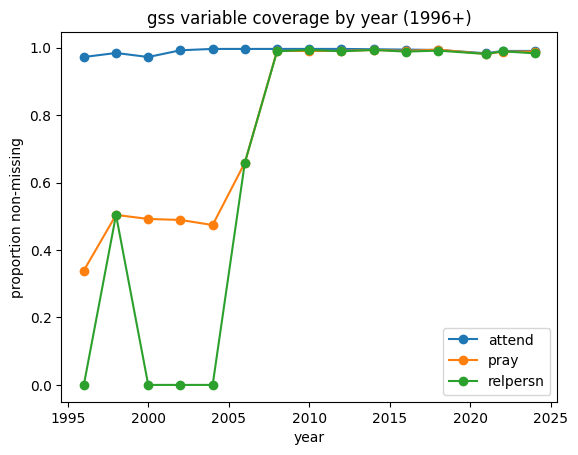

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# variables to check
vars_to_check = ["attend", "pray", "relpersn"]

# ensure column names are lowercase (safe if already lowercase)
df_96.columns = df_96.columns.str.lower()

# group by year and compute diagnostics
summary = df_96.groupby("year")[vars_to_check].agg(["count", "size"])

# compute proportion non-missing
prop_non_missing = df_96.groupby("year")[vars_to_check].apply(lambda x: x.notna().mean())

# combine into one table
coverage_table = prop_non_missing.round(3)

print("Proportion of non-missing values by year:")
print(coverage_table)

print("\nOverall completeness across all years:")
print(df_96[vars_to_check].notna().mean().round(3))

# optional quick visual check
coverage_table.plot(marker="o")
plt.ylabel("proportion non-missing")
plt.title("gss variable coverage by year (1996+)")
plt.show()

In [8]:
REL = ["attend", "pray"]

# Step 1 — global standardization
for c in REL:
    df_96[c + "_z"] = (df_96[c] - df_96[c].mean()) / df_96[c].std(ddof=0)

# Step 2 — reverse pray if higher values mean LESS prayer
df_96["pray_z"] = -df_96["pray_z"]

# Step 3 — build religiosity index
Z = [c + "_z" for c in REL]
df_96["religiosity_index"] = df_96[Z].mean(axis=1)

# Step 4 — require at least 1 valid item
df_96["relig_n_items"] = df_96[Z].notna().sum(axis=1)
df_96.loc[df_96["relig_n_items"] < 1, "religiosity_index"] = np.nan

C:\Users\honor\AppData\Local\Temp\ipykernel_33592\975042271.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_96[c + "_z"] = (df_96[c] - df_96[c].mean()) / df_96[c].std(ddof=0)
C:\Users\honor\AppData\Local\Temp\ipykernel_33592\975042271.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_96[c + "_z"] = (df_96[c] - df_96[c].mean()) / df_96[c].std(ddof=0)
C:\Users\honor\AppData\Local\Temp\ipykernel_33592\975042271.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

In [10]:
df_96["religiosity_index"].describe()

count    43050.000000
mean         0.011330
std          0.901759
min         -1.720431
25%         -0.826145
50%          0.005131
75%          0.821464
max          1.670923
Name: religiosity_index, dtype: float64

===== SAMPLE SIZE =====
Depression index: 31299
Religiosity index: 43050

===== DESCRIPTIVE STATISTICS =====
       depression_index  religiosity_index
count      31299.000000       43050.000000
mean           0.011633           0.011330
std            0.741648           0.901759
min           -1.330321          -1.720431
25%           -0.560598          -0.826145
50%            0.057051           0.005131
75%            0.527408           0.821464
max            2.411191           1.670923

===== MISSINGNESS =====
depression_index     0.277476
religiosity_index    0.006210
dtype: float64

===== COMPONENT CORRELATIONS =====

Depression variables
           happy      life    health
happy   1.000000  0.335128  0.284169
life    0.335128  1.000000  0.262939
health  0.284169  0.262939  1.000000

Religiosity variables
          attend      pray
attend  1.000000 -0.536914
pray   -0.536914  1.000000

===== CRONBACH ALPHA (DEPRESSION INDEX) =====
Alpha: 0.5441932069501845

===== RAW CORRELATIO

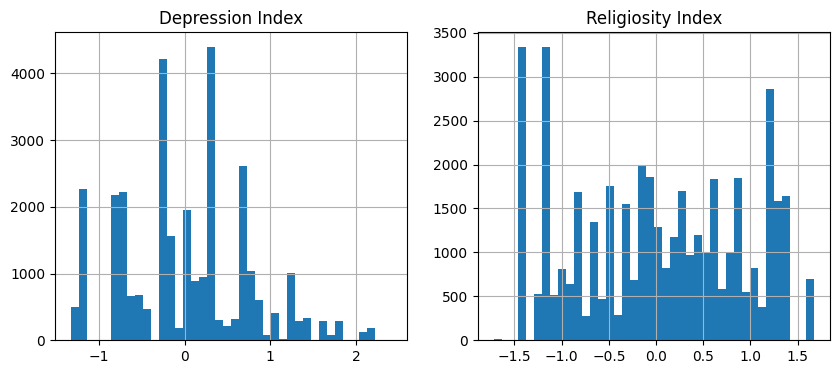


===== TIME TREND CHECK =====


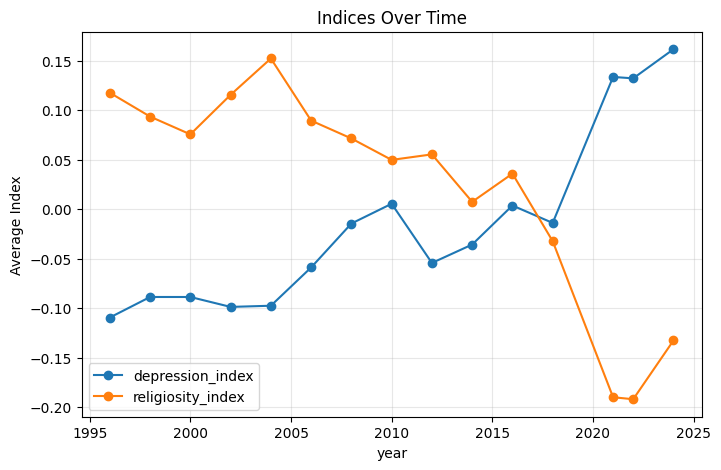

In [15]:
import numpy as np
import matplotlib.pyplot as plt

print("===== SAMPLE SIZE =====")
print("Depression index:", df_96["depression_index"].notna().sum())
print("Religiosity index:", df_96["religiosity_index"].notna().sum())

print("\n===== DESCRIPTIVE STATISTICS =====")
print(df_96[["depression_index","religiosity_index"]].describe())

print("\n===== MISSINGNESS =====")
print(df_96[["depression_index","religiosity_index"]].isna().mean())

print("\n===== COMPONENT CORRELATIONS =====")
print("\nDepression variables")
print(df_96[["happy","life","health"]].corr())

print("\nReligiosity variables")
print(df_96[["attend","pray"]].corr())

print("\n===== CRONBACH ALPHA (DEPRESSION INDEX) =====")
items = df_96[["happy","life","health"]].dropna()
k = items.shape[1]
alpha = (k/(k-1)) * (1 - items.var(ddof=1).sum()/items.sum(axis=1).var(ddof=1))
print("Alpha:", alpha)

print("\n===== RAW CORRELATION BETWEEN INDICES =====")
print(df_96[["religiosity_index","depression_index"]].corr())

print("\n===== DISTRIBUTIONS =====")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
df_96["depression_index"].hist(bins=40)
plt.title("Depression Index")

plt.subplot(1,2,2)
df_96["religiosity_index"].hist(bins=40)
plt.title("Religiosity Index")

plt.show()

print("\n===== TIME TREND CHECK =====")

df_96.groupby("year")[["depression_index","religiosity_index"]].mean().plot(marker="o", figsize=(8,5))
plt.title("Indices Over Time")
plt.ylabel("Average Index")
plt.grid(alpha=0.3)
plt.show()

===== INDEX RELIABILITY =====
Depression index alpha: 0.5441932069501845

Religiosity item correlation:
          attend      pray
attend  1.000000 -0.536914
pray   -0.536914  1.000000

===== INDEX CORRELATION =====
                   religiosity_index  depression_index
religiosity_index           1.000000         -0.107284
depression_index           -0.107284          1.000000

===== SAMPLE SIZE BY YEAR =====
      depression_index  religiosity_index
year                                     
1996              2417               2859
1998              2807               2806
2000              2303               2782
2002               923               2745
2004               898               2802
2006              2001               4496
2008              1350               2019
2010              1281               2037
2012              1306               1970
2014              1714               2529
2016              1886               2858
2018              1570               234

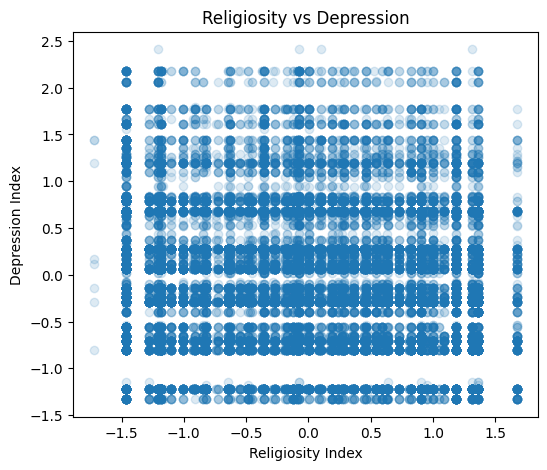


===== CHECK FOR YEAR TREND EFFECT =====


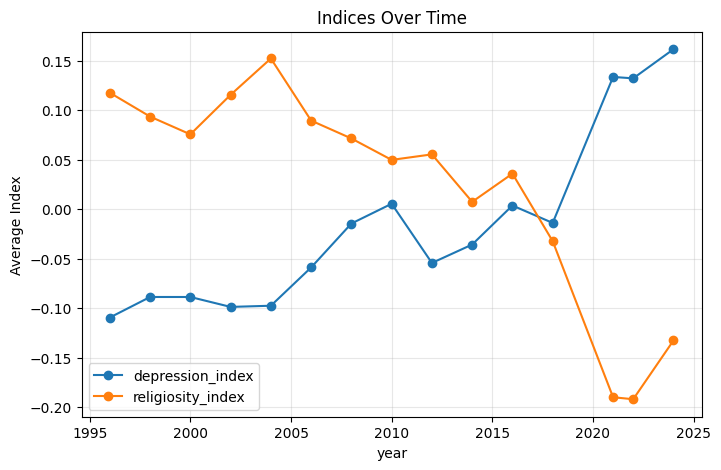

In [16]:
import numpy as np
import matplotlib.pyplot as plt

print("===== INDEX RELIABILITY =====")

# Cronbach alpha for depression index
items = df_96[["happy","life","health"]].dropna()
k = items.shape[1]
alpha = (k/(k-1)) * (1 - items.var(ddof=1).sum()/items.sum(axis=1).var(ddof=1))
print("Depression index alpha:", alpha)

# correlation for religiosity items
print("\nReligiosity item correlation:")
print(df_96[["attend","pray"]].corr())


print("\n===== INDEX CORRELATION =====")
print(df_96[["religiosity_index","depression_index"]].corr())


print("\n===== SAMPLE SIZE BY YEAR =====")
print(df_96.groupby("year")[["depression_index","religiosity_index"]].count())


print("\n===== MEAN VALUES BY YEAR =====")
print(df_96.groupby("year")[["depression_index","religiosity_index"]].mean())


print("\n===== CHECK FOR EXTREME VALUES =====")
print("Depression index range:", df_96["depression_index"].min(), df_96["depression_index"].max())
print("Religiosity index range:", df_96["religiosity_index"].min(), df_96["religiosity_index"].max())


print("\n===== SCATTERPLOT (RAW RELATIONSHIP) =====")

plt.figure(figsize=(6,5))
plt.scatter(
    df_96["religiosity_index"],
    df_96["depression_index"],
    alpha=0.15
)
plt.xlabel("Religiosity Index")
plt.ylabel("Depression Index")
plt.title("Religiosity vs Depression")
plt.show()


print("\n===== CHECK FOR YEAR TREND EFFECT =====")

df_96.groupby("year")[["depression_index","religiosity_index"]].mean().plot(marker="o", figsize=(8,5))
plt.title("Indices Over Time")
plt.ylabel("Average Index")
plt.grid(alpha=0.3)
plt.show()